In [ ]:
%reload_ext autoreload
%autoreload 2

from placefield_models import PlacefieldConfig, PlacefieldViewer

In [ ]:
cfg = PlacefieldConfig(
    n_neurons=8000,
    n_bins=100,
    normalize="peak",
    seed=0,
    tgp_amplitude=1.0,
    tgp_length_scale=0.6,
    tgp_threshold=0.25,
    tgp_periodic=True,
    pns_smooth_width=3.0,
    pns_alpha=1.5,
    pns_mean=0.0,
    pns_threshold=0.5,
    max_rate=10.0,
)
viewer = PlacefieldViewer(cfg)
viewer.show()

In [26]:
%reload_ext autoreload
%autoreload 2

from matplotlib import pyplot as plt
from my_precious_cvpca_simulation import (
    SimulationConfig,
    PlacefieldConfig,
    run_simulations,
    plot_results,
    plot_components,
)

prms_from = "best_optuna"
if prms_from == "here":
    lengthscale = 8.0
    threshold_pct = 60.0
    amplitude = 10.0
    repeat_noise_alpha = 10.0
    noise_level = 1.0
    smooth_width = 3.0
    peak_exponent = None

elif prms_from == "best_optuna":
    lengthscale = 2.33
    threshold_pct = 45.6
    amplitude = 2.75
    repeat_noise_alpha = 0.55
    noise_level = 0.1
    smooth_width = 9.01
    peak_exponent = 2.1

else:
    raise ValueError(f"Invalid prms_from: {prms_from}")

BASE = SimulationConfig(
    placefield=PlacefieldConfig(
        n_neurons=500,
        n_positions=100,
        lengthscale=lengthscale,
        threshold_pct=threshold_pct, 
        amplitude=amplitude,
        repeat_noise_alpha=repeat_noise_alpha,
        repeat_noise_lengthscale=5.0,
        peak_exponent=peak_exponent,
    ),
    noise_level=noise_level,
    n_repeats=3,
    normalize=True,
    center=True,
    smooth_width=smooth_width,
    n_components=80,
    n_simulations=20,
    seed=42,
)


print(f"Base simulation ({BASE.n_simulations} runs)...")
base_result = run_simulations(BASE)
print(f"  burn_in={base_result['burn_in']}  (spatial_rank + ns_modes)")
for key, label in [("frac_neg_cov_neuron", "neuron  "), ("frac_neg_cov_position", "position")]:
    fn = base_result[key]
    print(f"  {label} frac<0 @dim40/dim79: {fn[39]:.2f} / {fn[78]:.2f}")

Base simulation (20 runs)...


  burn_in=3  (spatial_rank + ns_modes)
  neuron   frac<0 @dim40/dim79: 0.15 / 0.00
  position frac<0 @dim40/dim79: 0.40 / 0.40


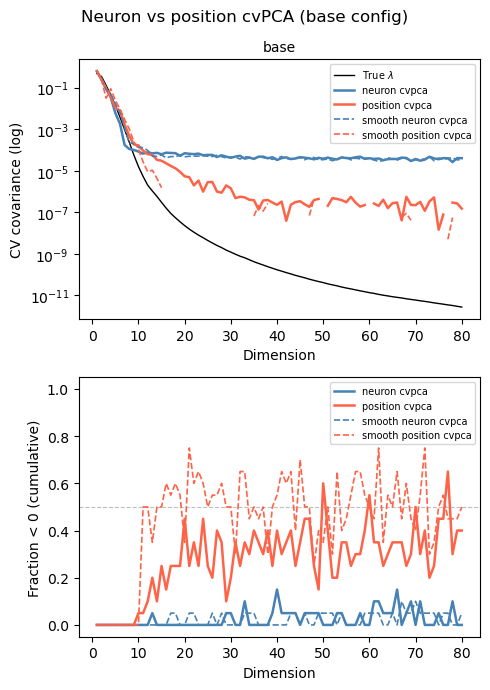

In [27]:
plot_results({"base": base_result}, suptitle="Neuron vs position cvPCA (base config)")
plt.show()

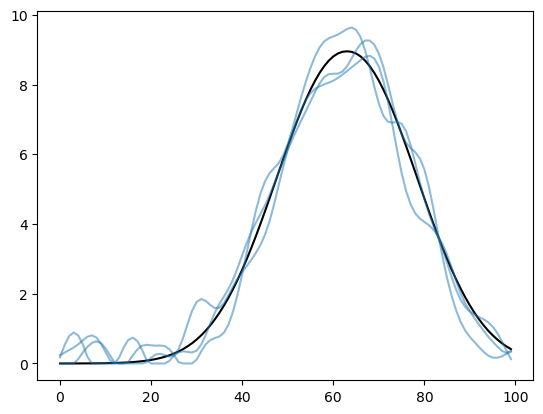

In [ ]:
# Plot placefield examples
import random

idx_sim = 0
idx_neuron = random.randint(0, BASE.placefield.n_neurons - 1)
num_repeats = len(base_result["pf_data"][idx_sim]["repeats"])
plt.close("all")
plt.plot(base_result["pf_data"][idx_sim]["source"][idx_neuron], color="k", linewidth=1.5)
for i in range(num_repeats):
    plt.plot(base_result["pf_data"][idx_sim]["repeats"][i][idx_neuron], color="C0", alpha=0.5)
plt.show()

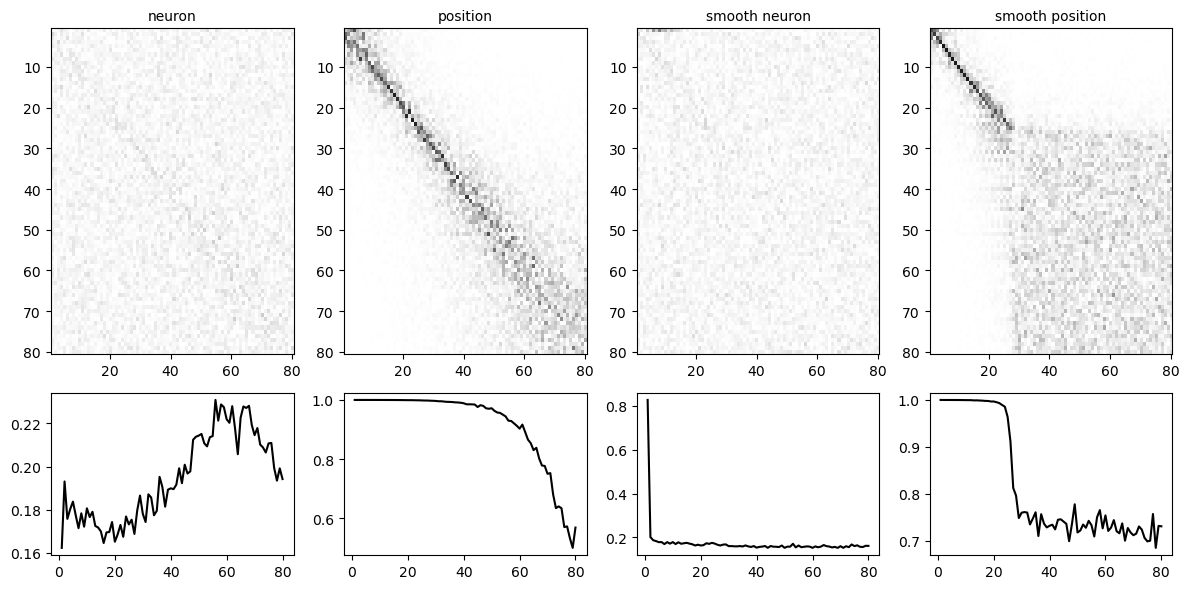

In [32]:
plot_components(base_result)
plt.show()